# CNN Training Pipeline — SmartAgriVision

## Import Libraries

In [1]:

import os
import random
import shutil
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

print("LIBRARIES LOADED")
print("TensorFlow:", tf.__version__)


LIBRARIES LOADED
TensorFlow: 2.21.0


## Reproducibility & Device

In [2]:

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("RANDOM SEED:", RANDOM_SEED)

gpu_devices = tf.config.list_physical_devices("GPU")

print("GPU Available:", bool(gpu_devices))

if gpu_devices:
    print("Device:", gpu_devices[0].name)
else:
    print("Device: CPU")


RANDOM SEED: 42
GPU Available: False
Device: CPU


## Dataset Paths & Configuration

In [3]:

NOTEBOOK_ROOT = Path(
    r"E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks"
)

CLEANED_DATASET_ROOT = NOTEBOOK_ROOT / "Cleaned_Dataset"
PREPROCESSED_DATASET_ROOT = NOTEBOOK_ROOT / "Preprocessed_Dataset"

CNN_DATASET_ROOT = NOTEBOOK_ROOT / "CNN_Classification_Dataset"
CNN_MODEL_ROOT = NOTEBOOK_ROOT / "CNN_Models"
CNN_RESULTS_ROOT = NOTEBOOK_ROOT / "CNN_Results"

CNN_DATASET_ROOT.mkdir(parents=True, exist_ok=True)
CNN_MODEL_ROOT.mkdir(parents=True, exist_ok=True)
CNN_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

print("PROJECT ROOT")
print(NOTEBOOK_ROOT)
print()

print("OUTPUT DIRECTORIES")
print("CNN Dataset:", CNN_DATASET_ROOT)
print("CNN Models:", CNN_MODEL_ROOT)
print("CNN Results:", CNN_RESULTS_ROOT)


PROJECT ROOT
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks

OUTPUT DIRECTORIES
CNN Dataset: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Classification_Dataset
CNN Models: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models
CNN Results: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results


In [4]:

paths_to_check = {
    "Project": NOTEBOOK_ROOT,
    "Cleaned Dataset": CLEANED_DATASET_ROOT,
    "Preprocessed Dataset": PREPROCESSED_DATASET_ROOT,
    "CNN Dataset": CNN_DATASET_ROOT,
    "CNN Models": CNN_MODEL_ROOT,
    "CNN Results": CNN_RESULTS_ROOT,
}

print("PATH EXISTENCE CHECK")

for name, path in paths_to_check.items():
    print(f"{name}: {path.exists()}")


PATH EXISTENCE CHECK
Project: True
Cleaned Dataset: True
Preprocessed Dataset: True
CNN Dataset: True
CNN Models: True
CNN Results: True


## Load Preprocessed Metadata

In [5]:

metadata_candidates = [
    PREPROCESSED_DATASET_ROOT / "metadata" / "image_metadata_preprocessed.csv",
    PREPROCESSED_DATASET_ROOT / "image_metadata_preprocessed.csv",
    NOTEBOOK_ROOT / "image_metadata_preprocessed.csv",
]

metadata_path = next(
    (p for p in metadata_candidates if p.exists()),
    None
)

if metadata_path is None:
    raise FileNotFoundError(
        "image_metadata_preprocessed.csv was not found."
    )

print("METADATA FOUND")
print(metadata_path)

image_metadata_df = pd.read_csv(metadata_path)

print("METADATA LOADED")
print("Rows:", f"{len(image_metadata_df):,}")
print("Columns:", len(image_metadata_df.columns))


METADATA FOUND
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\Preprocessed_Dataset\metadata\image_metadata_preprocessed.csv
METADATA LOADED
Rows: 294,695
Columns: 8


In [6]:

required_columns = [
    "Dataset",
    "Split",
    "Class",
    "Image_Path",
    "Filename",
]

missing_columns = [
    c for c in required_columns
    if c not in image_metadata_df.columns
]

if missing_columns:
    raise ValueError(
        f"Required metadata columns are missing: {missing_columns}"
    )

print("METADATA STRUCTURE")

for i, column in enumerate(image_metadata_df.columns, 1):
    print(f"{i}. {column}")

print()
print("Shape:", image_metadata_df.shape)
print()
print("Missing Values:")
print(image_metadata_df.isna().sum())


METADATA STRUCTURE
1. Dataset
2. Split
3. Class
4. Image_Path
5. Filename
6. Label
7. Encoded_Label
8. Processed_Split

Shape: (294695, 8)

Missing Values:
Dataset            0
Split              0
Class              0
Image_Path         0
Filename           0
Label              0
Encoded_Label      0
Processed_Split    0
dtype: int64


## CNN Dataset Preparation

In [7]:

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp"
}

EXPECTED_CLASSES = 82

def clean_text(value):
    if pd.isna(value):
        return ""
    return str(value).strip()

image_metadata_df["Class"] = (
    image_metadata_df["Class"]
    .map(clean_text)
)

image_metadata_df["Image_Path"] = (
    image_metadata_df["Image_Path"]
    .map(clean_text)
)

image_metadata_df["Filename"] = (
    image_metadata_df["Filename"]
    .map(clean_text)
)

class_names = sorted(
    image_metadata_df["Class"]
    .dropna()
    .unique()
)

NUM_CLASSES = len(class_names)

print("CLASS CONFIGURATION")
print("Detected classes:", NUM_CLASSES)
print("Expected classes:", EXPECTED_CLASSES)

if NUM_CLASSES != EXPECTED_CLASSES:
    raise ValueError(
        f"Expected {EXPECTED_CLASSES} classes, "
        f"but found {NUM_CLASSES}."
    )

class_to_id = {
    name: index
    for index, name in enumerate(class_names)
}

image_metadata_df["Class_ID"] = (
    image_metadata_df["Class"]
    .map(class_to_id)
)

print("Class mapping created.")


CLASS CONFIGURATION
Detected classes: 82
Expected classes: 82
Class mapping created.


In [8]:

def resolve_image_path(row):
    raw_path = clean_text(row.get("Image_Path", ""))
    filename = clean_text(row.get("Filename", ""))

    candidates = []

    if raw_path:
        candidates.append(Path(raw_path))

    if raw_path and filename:
        candidates.append(Path(raw_path) / filename)

    dataset_name = clean_text(row.get("Dataset", ""))

    if dataset_name and filename:
        candidates.extend([
            CLEANED_DATASET_ROOT / dataset_name / filename,
            PREPROCESSED_DATASET_ROOT / dataset_name / filename,
            NOTEBOOK_ROOT / dataset_name / filename,
        ])

    if filename:
        candidates.extend([
            CLEANED_DATASET_ROOT / filename,
            PREPROCESSED_DATASET_ROOT / filename,
            NOTEBOOK_ROOT / filename,
        ])

    for candidate in candidates:
        try:
            candidate = candidate.resolve()
        except Exception:
            candidate = Path(candidate)

        if candidate.exists() and candidate.is_file():
            if candidate.suffix.lower() in IMAGE_EXTENSIONS:
                return str(candidate)

    return None


image_metadata_df["Resolved_Image_Path"] = (
    image_metadata_df.apply(
        resolve_image_path,
        axis=1
    )
)

resolved_count = (
    image_metadata_df["Resolved_Image_Path"]
    .notna()
    .sum()
)

print("IMAGE PATH RESOLUTION")
print(
    "Resolved:",
    f"{resolved_count:,} / {len(image_metadata_df):,}"
)

if resolved_count == 0:
    raise RuntimeError(
        "No image paths could be resolved."
    )


IMAGE PATH RESOLUTION
Resolved: 294,695 / 294,695


In [9]:

split_column = (
    "Processed_Split"
    if "Processed_Split" in image_metadata_df.columns
    else "Split"
)

split_map = {
    "train": "train",
    "training": "train",
    "val": "val",
    "valid": "val",
    "validation": "val",
    "test": "test",
    "testing": "test",
}

image_metadata_df["Final_Split"] = (
    image_metadata_df[split_column]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(split_map)
    .fillna("unsplit")
)

print("SOURCE SPLIT DISTRIBUTION")
display(
    image_metadata_df["Final_Split"]
    .value_counts()
    .rename_axis("Split")
    .reset_index(name="Images")
)


SOURCE SPLIT DISTRIBUTION


,Split,Images
0,unsplit,182942
1,train,87937
2,val,20564
3,test,3252


In [10]:
# Deterministic class-aware split for records that do not already have a valid split.
# IMPORTANT: A class with fewer than 3 images cannot exist in all three splits.
# Such rare classes are kept in train only. This prevents accidental duplication/leakage.

rng = np.random.default_rng(RANDOM_SEED)

unsplit_mask = image_metadata_df["Final_Split"].eq("unsplit")

for class_name, group in image_metadata_df.loc[unsplit_mask].groupby("Class"):
    indices = group.index.to_numpy(copy=True)
    rng.shuffle(indices)
    n = len(indices)

    if n >= 3:
        # At least one image goes to each split.
        train_n = max(1, int(np.floor(0.80 * n)))
        val_n = max(1, int(np.floor(0.10 * n)))
        test_n = n - train_n - val_n

        if test_n < 1:
            test_n = 1
            train_n = max(1, n - val_n - test_n)

        if train_n + val_n + test_n != n:
            train_n = n - val_n - test_n

        image_metadata_df.loc[indices[:train_n], "Final_Split"] = "train"
        image_metadata_df.loc[indices[train_n:train_n + val_n], "Final_Split"] = "val"
        image_metadata_df.loc[indices[train_n + val_n:], "Final_Split"] = "test"
    else:
        # Cannot create three non-empty splits from <3 images.
        image_metadata_df.loc[indices, "Final_Split"] = "train"

image_metadata_df.loc[
    ~image_metadata_df["Final_Split"].isin(["train", "val", "test"]),
    "Final_Split"
] = "invalid"

print("FINAL SPLIT DISTRIBUTION")
display(
    image_metadata_df["Final_Split"]
    .value_counts()
    .rename_axis("Split")
    .reset_index(name="Images")
)


FINAL SPLIT DISTRIBUTION


,Split,Images
0,train,234290
1,val,38858
2,test,21547


In [11]:

cnn_ready_df = image_metadata_df[
    image_metadata_df["Final_Split"].isin(
        ["train", "val", "test"]
    )
    &
    image_metadata_df["Resolved_Image_Path"].notna()
].copy()

print("CNN USABLE RECORDS")
print("Total:", f"{len(cnn_ready_df):,}")

display(
    cnn_ready_df["Final_Split"]
    .value_counts()
    .rename_axis("Split")
    .reset_index(name="Images")
)


CNN USABLE RECORDS
Total: 294,695


,Split,Images
0,train,234290
1,val,38858
2,test,21547


In [12]:

split_class_table = (
    cnn_ready_df
    .groupby(["Final_Split", "Class"])
    .size()
    .unstack(fill_value=0)
)

split_validation_rows = []

for split_name in ["train", "val", "test"]:

    if split_name not in split_class_table.index:
        present_count = 0
        missing = class_names.copy()
    else:
        row = (
            split_class_table
            .loc[split_name]
            .reindex(class_names, fill_value=0)
        )

        present_count = int((row > 0).sum())
        missing = [
            cls for cls in class_names
            if row[cls] == 0
        ]

    split_validation_rows.append({
        "Split": split_name,
        "Classes_Present": present_count,
        "Expected_Classes": NUM_CLASSES,
        "Missing_Classes": len(missing),
        "Images": int(
            (cnn_ready_df["Final_Split"] == split_name).sum()
        ),
        "Ready": bool(
            (cnn_ready_df["Final_Split"] == split_name).sum() > 0
        )
    })

split_validation_df = pd.DataFrame(
    split_validation_rows
)

print("CNN SPLIT / CLASS VALIDATION")
display(split_validation_df)

print(
    "Note: rare classes with fewer than 3 source images "
    "remain in train only to prevent data leakage."
)


CNN SPLIT / CLASS VALIDATION


,Split,Classes_Present,Expected_Classes,Missing_Classes,Images,Ready
0,train,82,82,0,234290,True
1,val,54,82,28,38858,True
2,test,43,82,39,21547,True


Note: rare classes with fewer than 3 source images remain in train only to prevent data leakage.


# Build CNN Classification Dataset

In [13]:
# Materialize the CNN dataset into the standard Keras directory structure:
#
# CNN_Classification_Dataset/
#   train/<class>/*
#   val/<class>/*
#   test/<class>/*
#
# Training below still uses the metadata paths directly, so the folder dataset is
# a verified export/backup and can also be used by other notebooks.

CNN_SPLIT_DIRS = {
    "train": CNN_DATASET_ROOT / "train",
    "val": CNN_DATASET_ROOT / "val",
    "test": CNN_DATASET_ROOT / "test",
}

for split_path in CNN_SPLIT_DIRS.values():
    split_path.mkdir(parents=True, exist_ok=True)

print("CNN DATASET DIRECTORIES")
for split, path in CNN_SPLIT_DIRS.items():
    print(f"{split}: {path} | Exists: {path.exists()}")


CNN DATASET DIRECTORIES
train: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Classification_Dataset\train | Exists: True
val: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Classification_Dataset\val | Exists: True
test: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Classification_Dataset\test | Exists: True


In [14]:
# Fast, resumable image materialization.
# First tries a hard-link (very fast and saves disk space when source/destination
# are on the same drive). If that is unavailable, falls back to a normal copy.

def safe_class_folder_name(value):
    name = str(value).strip()
    # Windows-invalid filename characters are replaced.
    for ch in '<>:"/\\|?*':
        name = name.replace(ch, "_")
    name = name.rstrip(". ")
    return name or "Unknown_Class"

def materialize_image(src_path, dst_path):
    try:
        src = Path(src_path)
        dst = Path(dst_path)

        if not src.exists() or not src.is_file():
            return "missing"

        dst.parent.mkdir(parents=True, exist_ok=True)

        if dst.exists():
            try:
                if dst.stat().st_size == src.stat().st_size:
                    return "existing"
                dst.unlink()
            except Exception:
                return "failed"

        # Fast path on same filesystem.
        try:
            os.link(src, dst)
            return "linked"
        except Exception:
            pass

        shutil.copyfile(src, dst)
        return "copied"

    except Exception:
        return "failed"


materialize_df = cnn_ready_df[
    cnn_ready_df["Final_Split"].isin(["train", "val", "test"])
].copy()

# Keep only image files with a valid source path.
materialize_df = materialize_df[
    materialize_df["Resolved_Image_Path"].notna()
].copy()

materialize_rows = []

for split in ["train", "val", "test"]:
    split_df = materialize_df[
        materialize_df["Final_Split"].eq(split)
    ]

    linked = copied = existing = missing = failed = 0

    for _, row in split_df.iterrows():
        src_path = Path(str(row["Resolved_Image_Path"]))
        class_folder = safe_class_folder_name(row["Class"])

        # Keep the original filename but make collision handling deterministic.
        dst_path = (
            CNN_SPLIT_DIRS[split]
            / class_folder
            / src_path.name
        )

        status = materialize_image(src_path, dst_path)

        if status == "linked":
            linked += 1
        elif status == "copied":
            copied += 1
        elif status == "existing":
            existing += 1
        elif status == "missing":
            missing += 1
        else:
            failed += 1

    materialize_rows.append({
        "Split": split,
        "Source_Records": len(split_df),
        "Linked": linked,
        "Copied": copied,
        "Existing": existing,
        "Missing": missing,
        "Failed": failed,
    })

materialize_summary_df = pd.DataFrame(materialize_rows)

print("CNN DATASET MATERIALIZATION SUMMARY")
display(materialize_summary_df)


CNN DATASET MATERIALIZATION SUMMARY


,Split,Source_Records,Linked,Copied,Existing,Missing,Failed
0,train,234290,234232,0,58,0,0
1,val,38858,38854,0,4,0,0
2,test,21547,21541,0,6,0,0


In [15]:
# Verify the actual physical CNN folder dataset.
# This is the important check that was missing before.

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

cnn_structure_rows = []

for split, split_path in CNN_SPLIT_DIRS.items():
    class_dirs = [
        p for p in split_path.iterdir()
        if p.is_dir()
    ] if split_path.exists() else []

    image_count = sum(
        1
        for class_dir in class_dirs
        for p in class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    present_classes = {p.name for p in class_dirs}

    cnn_structure_rows.append({
        "Split": split,
        "Class_Folders": len(class_dirs),
        "Images": image_count,
        "Ready": len(class_dirs) > 0 and image_count > 0,
        "Expected_Classes": NUM_CLASSES,
        "All_Classes_Present": len(present_classes) == NUM_CLASSES,
    })

cnn_structure_df = pd.DataFrame(cnn_structure_rows)

print("CNN DATASET PHYSICAL CHECK")
display(cnn_structure_df)

CNN_FOLDER_READY = bool(
    cnn_structure_df["Ready"].all()
)

print("CNN Folder Dataset Ready:", CNN_FOLDER_READY)

if not CNN_FOLDER_READY:
    raise RuntimeError(
        "CNN dataset materialization failed: one or more split folders "
        "contains no images."
    )

print("CNN train/val/test folders contain physical image files.")


CNN DATASET PHYSICAL CHECK


,Split,Class_Folders,Images,Ready,Expected_Classes,All_Classes_Present
0,train,82,90482,True,82,True
1,val,54,22468,True,82,False
2,test,43,5157,True,82,False


CNN Folder Dataset Ready: True
CNN train/val/test folders contain physical image files.


## Image & Training Configuration

In [16]:

IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 1e-3
NUM_CHANNELS = 3

# Optional quick-test limit.
# Set to None for the full dataset.
MAX_TRAIN_SAMPLES = None
MAX_VAL_SAMPLES = None
MAX_TEST_SAMPLES = None

print("CNN CPU-FRIENDLY CONFIGURATION")
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Channels:", NUM_CHANNELS)
print("Max train samples:", MAX_TRAIN_SAMPLES)


CNN CPU-FRIENDLY CONFIGURATION
Image size: 128
Batch size: 32
Epochs: 3
Learning rate: 0.001
Channels: 3
Max train samples: None


In [17]:

# Apply optional sample limits without changing the saved metadata.

def limit_dataframe(df, max_samples):
    if max_samples is None or len(df) <= max_samples:
        return df.copy()

    return (
        df.sample(
            n=max_samples,
            random_state=RANDOM_SEED
        )
        .sort_index()
        .copy()
    )


train_df = limit_dataframe(
    cnn_ready_df[cnn_ready_df["Final_Split"] == "train"],
    MAX_TRAIN_SAMPLES
)

validation_df = limit_dataframe(
    cnn_ready_df[cnn_ready_df["Final_Split"] == "val"],
    MAX_VAL_SAMPLES
)

test_df = limit_dataframe(
    cnn_ready_df[cnn_ready_df["Final_Split"] == "test"],
    MAX_TEST_SAMPLES
)

print("TRAINING DATAFRAME COUNTS")
print("Train:", f"{len(train_df):,}")
print("Validation:", f"{len(validation_df):,}")
print("Test:", f"{len(test_df):,}")


TRAINING DATAFRAME COUNTS
Train: 234,290
Validation: 38,858
Test: 21,547


## Image Data Loading

In [18]:

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

test_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

generator_args = {
    "x_col": "Resolved_Image_Path",
    "y_col": "Class",
    "target_size": (IMAGE_SIZE, IMAGE_SIZE),
    "color_mode": "rgb",
    "class_mode": "sparse",
    "classes": class_names,
    "batch_size": BATCH_SIZE
}

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    shuffle=True,
    seed=RANDOM_SEED,
    **generator_args
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    shuffle=False,
    **generator_args
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    shuffle=False,
    **generator_args
)

print("DATA GENERATORS READY")
print("Train:", f"{train_generator.samples:,}")
print("Validation:", f"{validation_generator.samples:,}")
print("Test:", f"{test_generator.samples:,}")
print("Classes:", len(train_generator.class_indices))

if not (
    train_generator.class_indices
    == validation_generator.class_indices
    == test_generator.class_indices
):
    raise RuntimeError(
        "Generator class mappings are inconsistent."
    )


Found 234290 validated image filenames belonging to 82 classes.
Found 38858 validated image filenames belonging to 82 classes.
Found 21547 validated image filenames belonging to 82 classes.
DATA GENERATORS READY
Train: 234,290
Validation: 38,858
Test: 21,547
Classes: 82


## CNN Model Architecture

In [19]:

cnn_model = models.Sequential(
    [
        layers.Input(
            shape=(
                IMAGE_SIZE,
                IMAGE_SIZE,
                NUM_CHANNELS
            )
        ),

        layers.Conv2D(
            32,
            3,
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            64,
            3,
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            128,
            3,
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D(2),

        layers.Conv2D(
            256,
            3,
            padding="same",
            activation="relu"
        ),
        layers.MaxPooling2D(2),

        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.40),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.30),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ],
    name="SmartAgriVision_CNN"
)

print("CNN MODEL CREATED")
cnn_model.summary()


CNN MODEL CREATED


Model: "SmartAgriVision_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 82)                  │          21,074 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 475,282 (1.81 MB)

 Trainable params: 475,282 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:

print("MODEL SUMMARY")
print("Input Shape:", cnn_model.input_shape)
print("Output Shape:", cnn_model.output_shape)
print("Total Parameters:", f"{cnn_model.count_params():,}")


MODEL SUMMARY
Input Shape: (None, 128, 128, 3)
Output Shape: (None, 82)
Total Parameters: 475,282


## Model Compilation

In [21]:

cnn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("CNN MODEL COMPILED")
print("Optimizer: Adam")
print("Learning Rate:", LEARNING_RATE)
print("Loss: Sparse Categorical Crossentropy")
print("Metric: Accuracy")


CNN MODEL COMPILED
Optimizer: Adam
Learning Rate: 0.001
Loss: Sparse Categorical Crossentropy
Metric: Accuracy


## CNN Model Training

In [22]:

BEST_MODEL_PATH = (
    CNN_MODEL_ROOT / "best_cnn_model.keras"
)

FINAL_MODEL_PATH = (
    CNN_MODEL_ROOT / "final_cnn_model.keras"
)

HISTORY_PATH = (
    CNN_RESULTS_ROOT / "training_history.csv"
)

PERFORMANCE_PATH = (
    CNN_RESULTS_ROOT / "cnn_performance_metrics.csv"
)

CLASSIFICATION_REPORT_PATH = (
    CNN_RESULTS_ROOT / "classification_report.csv"
)

CONFUSION_MATRIX_PATH = (
    CNN_RESULTS_ROOT / "confusion_matrix.csv"
)

PREDICTION_RESULTS_PATH = (
    CNN_RESULTS_ROOT / "cnn_prediction_results.csv"
)

print("TRAINING OUTPUT PATHS")
print("Best:", BEST_MODEL_PATH)
print("Final:", FINAL_MODEL_PATH)
print("Results:", CNN_RESULTS_ROOT)


TRAINING OUTPUT PATHS
Best: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
Final: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\final_cnn_model.keras
Results: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results


In [23]:

early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(BEST_MODEL_PATH),
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

learning_rate_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("CNN CALLBACKS READY")


CNN CALLBACKS READY


In [24]:

dataset_ready = (
    len(train_df) > 0
    and len(validation_df) > 0
    and len(test_df) > 0
    and NUM_CLASSES == EXPECTED_CLASSES
)

model_ready = (
    cnn_model is not None
    and cnn_model.output_shape[-1] == NUM_CLASSES
)

training_ready = (
    dataset_ready
    and model_ready
)

print("FINAL TRAINING SAFETY CHECK")
print("Dataset ready:", dataset_ready)
print("82 classes:", NUM_CLASSES == EXPECTED_CLASSES)
print("Model ready:", model_ready)
print("Training ready:", training_ready)

history = None

if not training_ready:
    raise RuntimeError(
        "Training safety check failed. "
        "Inspect dataset/model readiness before training."
    )

print("CNN TRAINING STARTED")

history = cnn_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=[
        early_stopping,
        model_checkpoint,
        learning_rate_scheduler
    ],
    verbose=1
)

print("CNN TRAINING COMPLETED")


FINAL TRAINING SAFETY CHECK
Dataset ready: True
82 classes: True
Model ready: True
Training ready: True
CNN TRAINING STARTED
Epoch 1/3
7322/7322 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.7520 - loss: 0.9247
Epoch 1: val_accuracy improved from None to 0.81733, saving model to E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras

Epoch 1: finished saving model to E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
7322/7322 ━━━━━━━━━━━━━━━━━━━━ 4221s 576ms/step - accuracy: 0.7520 - loss: 0.9247 - val_accuracy: 0.8173 - val_loss: 0.5806 - learning_rate: 0.0010
Epoch 2/3
7322/7322 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.8729 - loss: 0.4380
Epoch 2: val_accuracy improved from 0.81733 to 0.87465, saving model to E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_m

In [25]:

history_df = pd.DataFrame(history.history)
history_df.index.name = "Epoch"

history_df.to_csv(
    HISTORY_PATH,
    index=True
)

print("TRAINING HISTORY SAVED")
print(HISTORY_PATH)


TRAINING HISTORY SAVED
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\training_history.csv


## Training Results Analysis

In [26]:

print("AVAILABLE TRAINING METRICS")

for column in history_df.columns:
    print(column)

print()
print("ACCURACY ANALYSIS")

print(
    "Best Training Accuracy:",
    f"{history_df['accuracy'].max():.4f}"
)

print(
    "Best Validation Accuracy:",
    f"{history_df['val_accuracy'].max():.4f}"
)

print(
    "Final Training Accuracy:",
    f"{history_df['accuracy'].iloc[-1]:.4f}"
)

print(
    "Final Validation Accuracy:",
    f"{history_df['val_accuracy'].iloc[-1]:.4f}"
)


AVAILABLE TRAINING METRICS
accuracy
loss
val_accuracy
val_loss
learning_rate

ACCURACY ANALYSIS
Best Training Accuracy: 0.9079
Best Validation Accuracy: 0.9202
Final Training Accuracy: 0.9079
Final Validation Accuracy: 0.9202


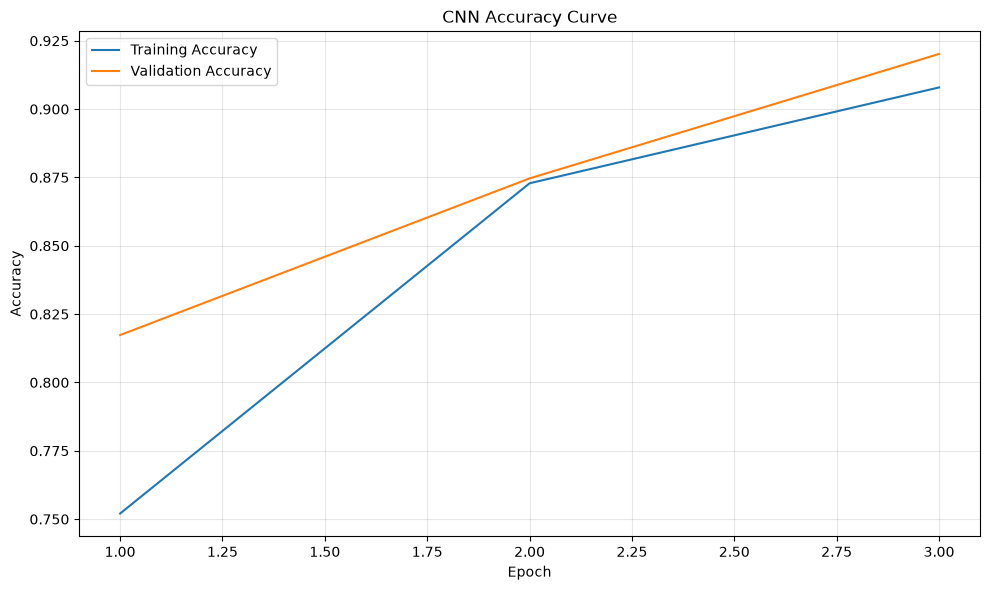

In [27]:

plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index + 1,
    history_df["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df.index + 1,
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


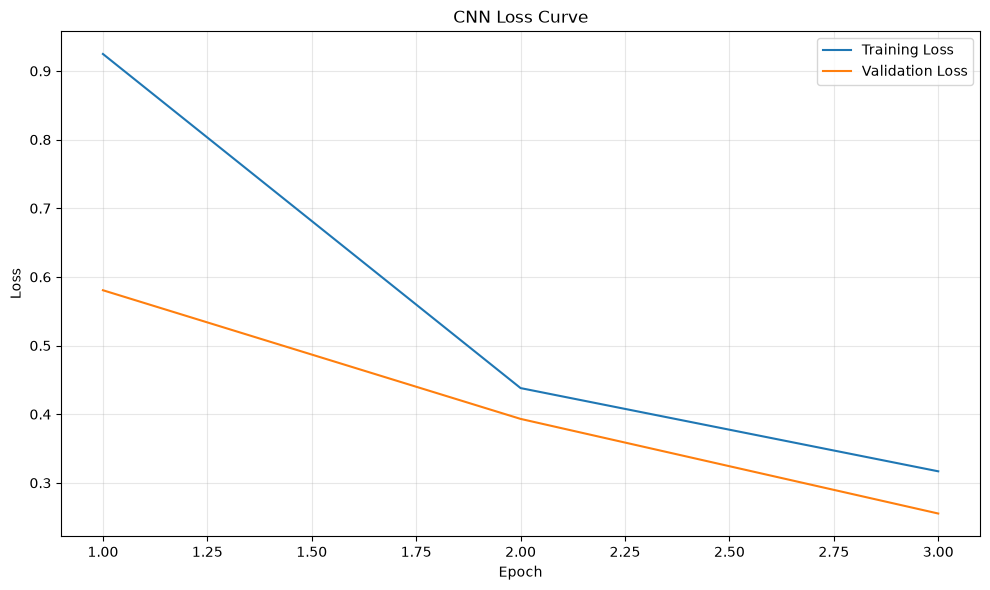

TRAINING BEHAVIOR
Possible underfitting.


In [28]:

plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index + 1,
    history_df["loss"],
    label="Training Loss"
)

plt.plot(
    history_df.index + 1,
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_loss = history_df["loss"].iloc[-1]
val_loss = history_df["val_loss"].iloc[-1]

print("TRAINING BEHAVIOR")

if val_loss > train_loss * 1.20:
    print("Possible overfitting.")
elif train_loss > val_loss * 1.20:
    print("Possible underfitting.")
else:
    print("Training appears reasonably stable.")


## Model Validation

In [29]:

validation_eval = cnn_model.evaluate(
    validation_generator,
    verbose=1
)

validation_loss = float(validation_eval[0])
validation_accuracy = float(validation_eval[1])

print("VALIDATION DATASET EVALUATION")
print("Validation Loss:", f"{validation_loss:.4f}")
print("Validation Accuracy:", f"{validation_accuracy:.4f}")


1215/1215 ━━━━━━━━━━━━━━━━━━━━ 183s 150ms/step - accuracy: 0.9202 - loss: 0.2553
VALIDATION DATASET EVALUATION
Validation Loss: 0.2553
Validation Accuracy: 0.9202


In [30]:

test_eval = cnn_model.evaluate(
    test_generator,
    verbose=1
)

test_loss = float(test_eval[0])
test_accuracy = float(test_eval[1])

print("TEST DATASET EVALUATION")
print("Test Loss:", f"{test_loss:.4f}")
print("Test Accuracy:", f"{test_accuracy:.4f}")


674/674 ━━━━━━━━━━━━━━━━━━━━ 106s 157ms/step - accuracy: 0.9588 - loss: 0.1705
TEST DATASET EVALUATION
Test Loss: 0.1705
Test Accuracy: 0.9588


## Confusion Matrix & Classification Report

In [31]:

test_generator.reset()

prediction_probabilities = cnn_model.predict(
    test_generator,
    verbose=1
)

predicted_labels = np.argmax(
    prediction_probabilities,
    axis=1
)

true_labels = np.asarray(
    test_generator.classes
)

print("TEST PREDICTIONS GENERATED")
print("Samples:", f"{len(true_labels):,}")


674/674 ━━━━━━━━━━━━━━━━━━━━ 105s 156ms/step
TEST PREDICTIONS GENERATED
Samples: 21,547


In [32]:

# Only classes with actual test support are used for macro metrics.
# This avoids artificially lowering macro metrics because some
# rare classes have no test samples.

supported_labels = sorted(
    np.unique(true_labels).tolist()
)

test_precision = precision_score(
    true_labels,
    predicted_labels,
    labels=supported_labels,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    true_labels,
    predicted_labels,
    labels=supported_labels,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    true_labels,
    predicted_labels,
    labels=supported_labels,
    average="macro",
    zero_division=0
)

print("TEST CLASSIFICATION METRICS")
print("Accuracy:", f"{test_accuracy:.4f}")
print("Macro Precision:", f"{test_precision:.4f}")
print("Macro Recall:", f"{test_recall:.4f}")
print("Macro F1-Score:", f"{test_f1:.4f}")
print("Classes with test support:", len(supported_labels))
print("Classes without test support:", NUM_CLASSES - len(supported_labels))


TEST CLASSIFICATION METRICS
Accuracy: 0.9588
Macro Precision: 0.3650
Macro Recall: 0.3772
Macro F1-Score: 0.3497
Classes with test support: 43
Classes without test support: 39


In [33]:

classification_report_dict = classification_report(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_report_dict
).T

print("CLASSIFICATION REPORT")
display(classification_report_df)


CLASSIFICATION REPORT


,precision,recall,f1-score,support
Apple_Scab_Leaf,0.000000,0.000000,0.000000,10.000000
Apple___Apple_scab,0.000000,0.000000,0.000000,0.000000
Apple___Black_rot,0.000000,0.000000,0.000000,0.000000
Apple___Cedar_apple_rust,0.000000,0.000000,0.000000,0.000000
Apple___healthy,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
grape_leaf,0.000000,0.000000,0.000000,12.000000
grape_leaf_black_rot,0.000000,0.000000,0.000000,8.000000
accuracy,0.958788,0.958788,0.958788,0.958788
macro avg,0.191388,0.197808,0.183400,21547.000000


CONFUSION MATRIX
Matrix Shape: (82, 82)


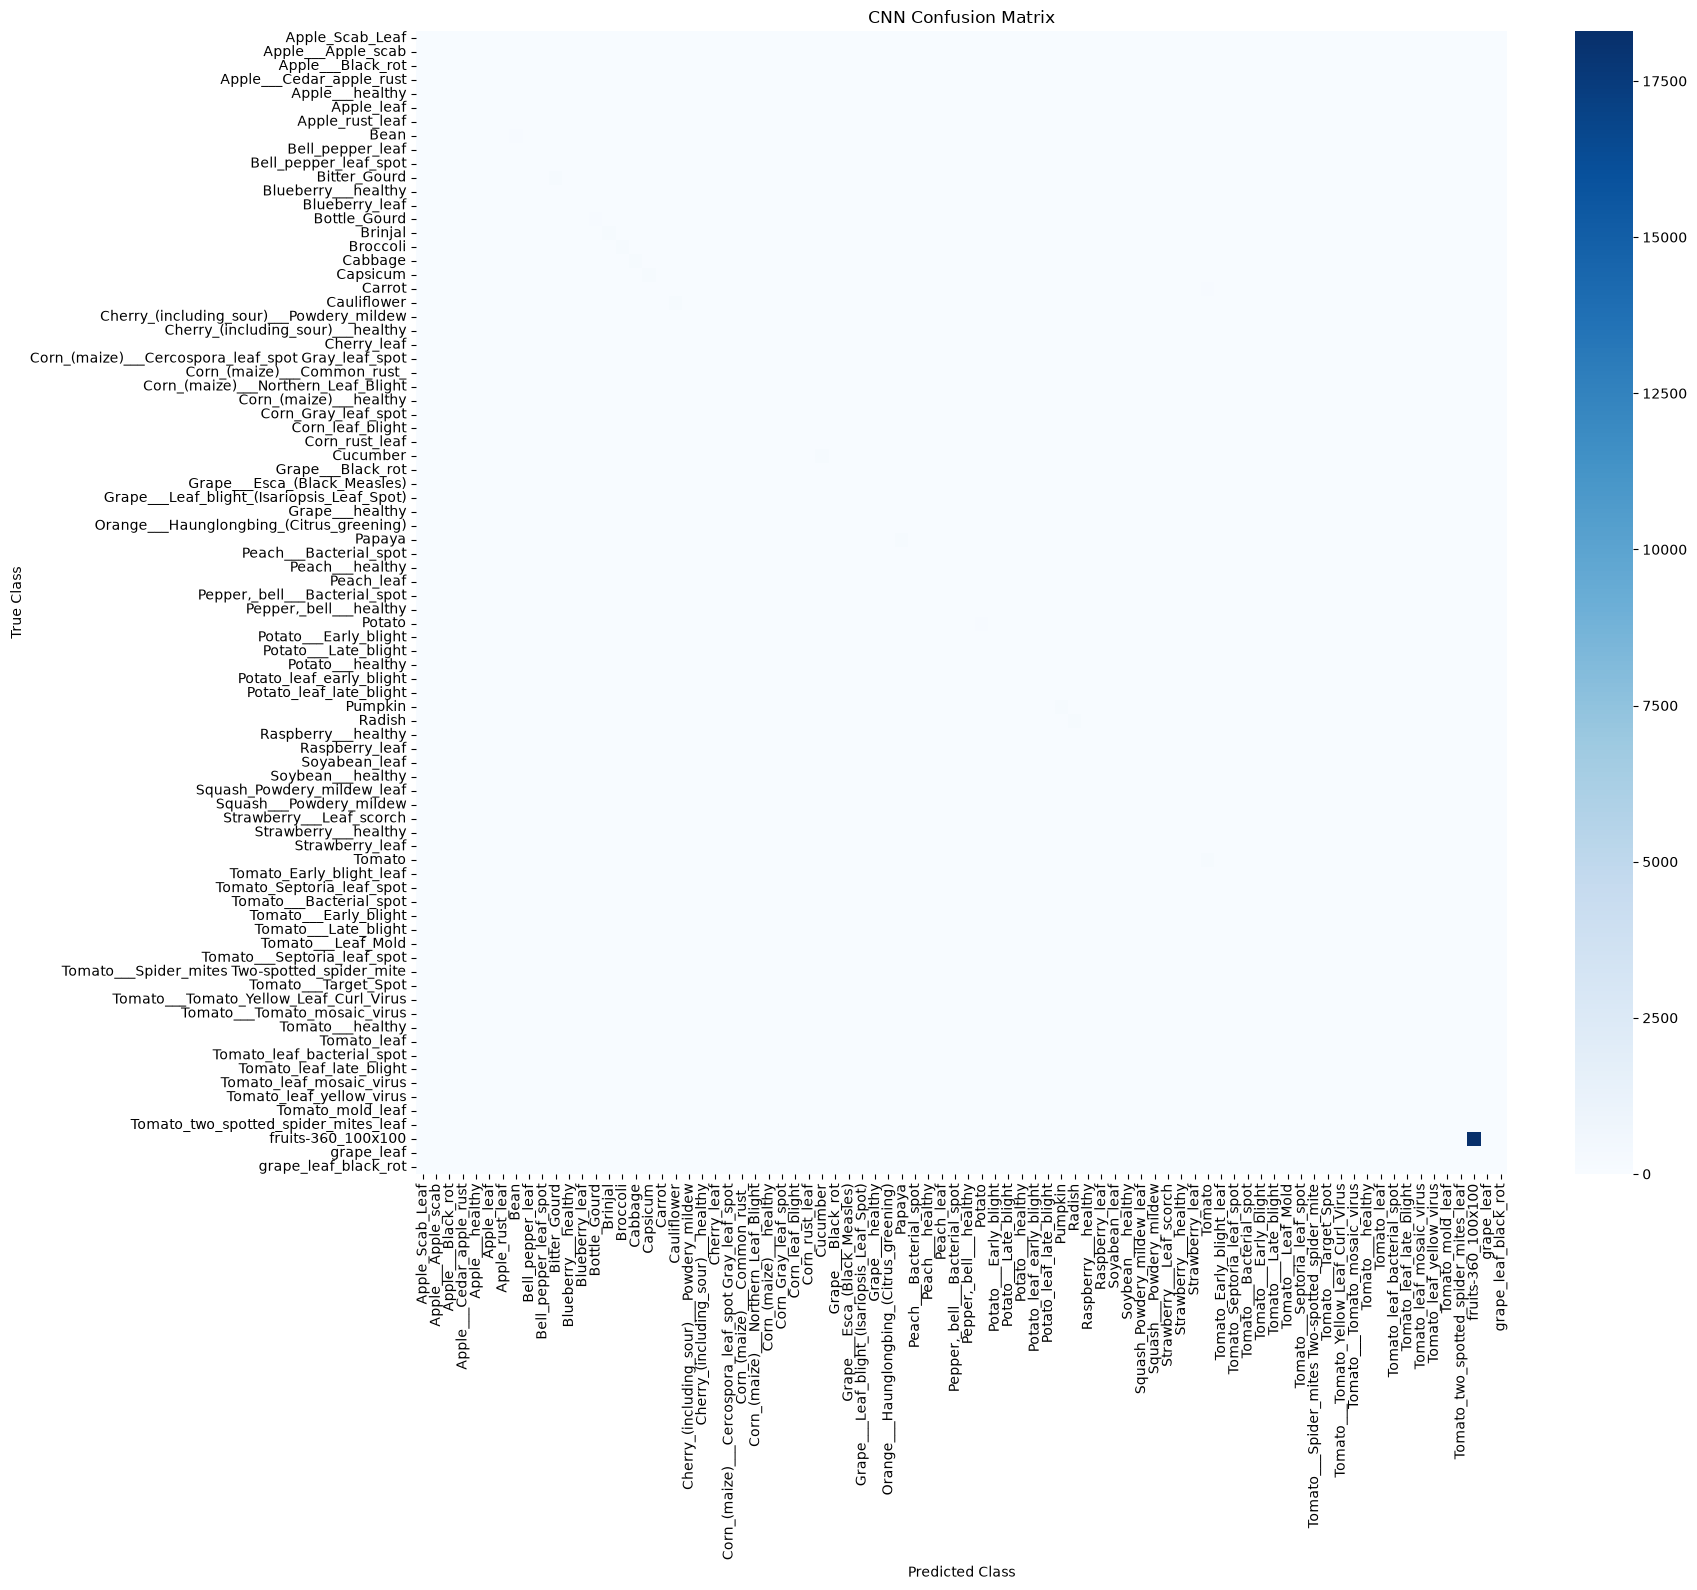

In [34]:

confusion_matrix_values = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=np.arange(NUM_CLASSES)
)

print("CONFUSION MATRIX")
print("Matrix Shape:", confusion_matrix_values.shape)

plt.figure(figsize=(18, 16))

sns.heatmap(
    confusion_matrix_values,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.show()


In [35]:

class_report_only = classification_report_df[
    ~classification_report_df.index.isin(
        ["accuracy", "macro avg", "weighted avg"]
    )
].copy()

zero_support_classes = class_report_only[
    class_report_only["support"] == 0
]

print("TOP 10 BEST PERFORMING CLASSES")

display(
    class_report_only
    .sort_values("f1-score", ascending=False)
    .head(10)
)

print("TOP 10 WORST PERFORMING CLASSES WITH TEST SUPPORT")

display(
    class_report_only[
        class_report_only["support"] > 0
    ]
    .sort_values("f1-score")
    .head(10)
)

if len(zero_support_classes) > 0:
    print("CLASSES WITHOUT TEST SAMPLES")
    display(
        zero_support_classes[["support"]]
    )


TOP 10 BEST PERFORMING CLASSES


,precision,recall,f1-score,support
fruits-360_100x100,0.995971,1.000,0.997982,18295.0
Radish,0.984848,0.975,0.979899,200.0
Cabbage,0.929730,0.860,0.893506,200.0
Broccoli,0.878641,0.905,0.891626,200.0
Pumpkin,0.865979,0.840,0.852792,200.0
Cauliflower,0.836634,0.845,0.840796,200.0
Cucumber,0.932515,0.760,0.837466,200.0
Potato,1.000000,0.705,0.826979,200.0
Capsicum,0.741036,0.930,0.824834,200.0
Papaya,0.847059,0.720,0.778378,200.0


TOP 10 WORST PERFORMING CLASSES WITH TEST SUPPORT


,precision,recall,f1-score,support
Apple_Scab_Leaf,0.0,0.0,0.0,10.0
Apple_leaf,0.0,0.0,0.0,9.0
Bell_pepper_leaf_spot,0.0,0.0,0.0,9.0
Bell_pepper_leaf,0.0,0.0,0.0,8.0
Blueberry_leaf,0.0,0.0,0.0,11.0
Cherry_leaf,0.0,0.0,0.0,10.0
Corn_rust_leaf,0.0,0.0,0.0,10.0
Corn_Gray_leaf_spot,0.0,0.0,0.0,4.0
Raspberry_leaf,0.0,0.0,0.0,7.0
Soyabean_leaf,0.0,0.0,0.0,8.0


CLASSES WITHOUT TEST SAMPLES


,support
Apple___Apple_scab,0.0
Apple___Black_rot,0.0
Apple___Cedar_apple_rust,0.0
Apple___healthy,0.0
Blueberry___healthy,0.0
Cherry_(including_sour)___Powdery_mildew,0.0
Cherry_(including_sour)___healthy,0.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.0
Corn_(maize)___Common_rust_,0.0
Corn_(maize)___Northern_Leaf_Blight,0.0


## CNN Prediction Visualization

In [36]:

test_dataset_order = test_df.reset_index(drop=True)

prediction_results_df = pd.DataFrame({
    "Image_Path": test_dataset_order[
        "Resolved_Image_Path"
    ].astype(str),

    "Dataset": test_dataset_order[
        "Dataset"
    ].astype(str),

    "Actual_Class": [
        class_names[i]
        for i in true_labels
    ],

    "Predicted_Class": [
        class_names[i]
        for i in predicted_labels
    ],

    "Confidence": np.max(
        prediction_probabilities,
        axis=1
    )
})

prediction_results_df["Correct"] = (
    prediction_results_df["Actual_Class"]
    ==
    prediction_results_df["Predicted_Class"]
)

print("PREDICTION RESULTS")
print("Total:", len(prediction_results_df))
print(
    "Correct:",
    int(prediction_results_df["Correct"].sum())
)
print(
    "Incorrect:",
    int((~prediction_results_df["Correct"]).sum())
)

display(prediction_results_df.head())


PREDICTION RESULTS
Total: 21547
Correct: 20659
Incorrect: 888


,Image_Path,Dataset,Actual_Class,Predicted_Class,Confidence,Correct
0,E:\programming languages\DJANGO PROJECT\SmartA...,Fruits-360,fruits-360_100x100,fruits-360_100x100,1.0,True
1,E:\programming languages\DJANGO PROJECT\SmartA...,Fruits-360,fruits-360_100x100,fruits-360_100x100,1.0,True
2,E:\programming languages\DJANGO PROJECT\SmartA...,Fruits-360,fruits-360_100x100,fruits-360_100x100,1.0,True
3,E:\programming languages\DJANGO PROJECT\SmartA...,Fruits-360,fruits-360_100x100,fruits-360_100x100,1.0,True
4,E:\programming languages\DJANGO PROJECT\SmartA...,Fruits-360,fruits-360_100x100,fruits-360_100x100,1.0,True


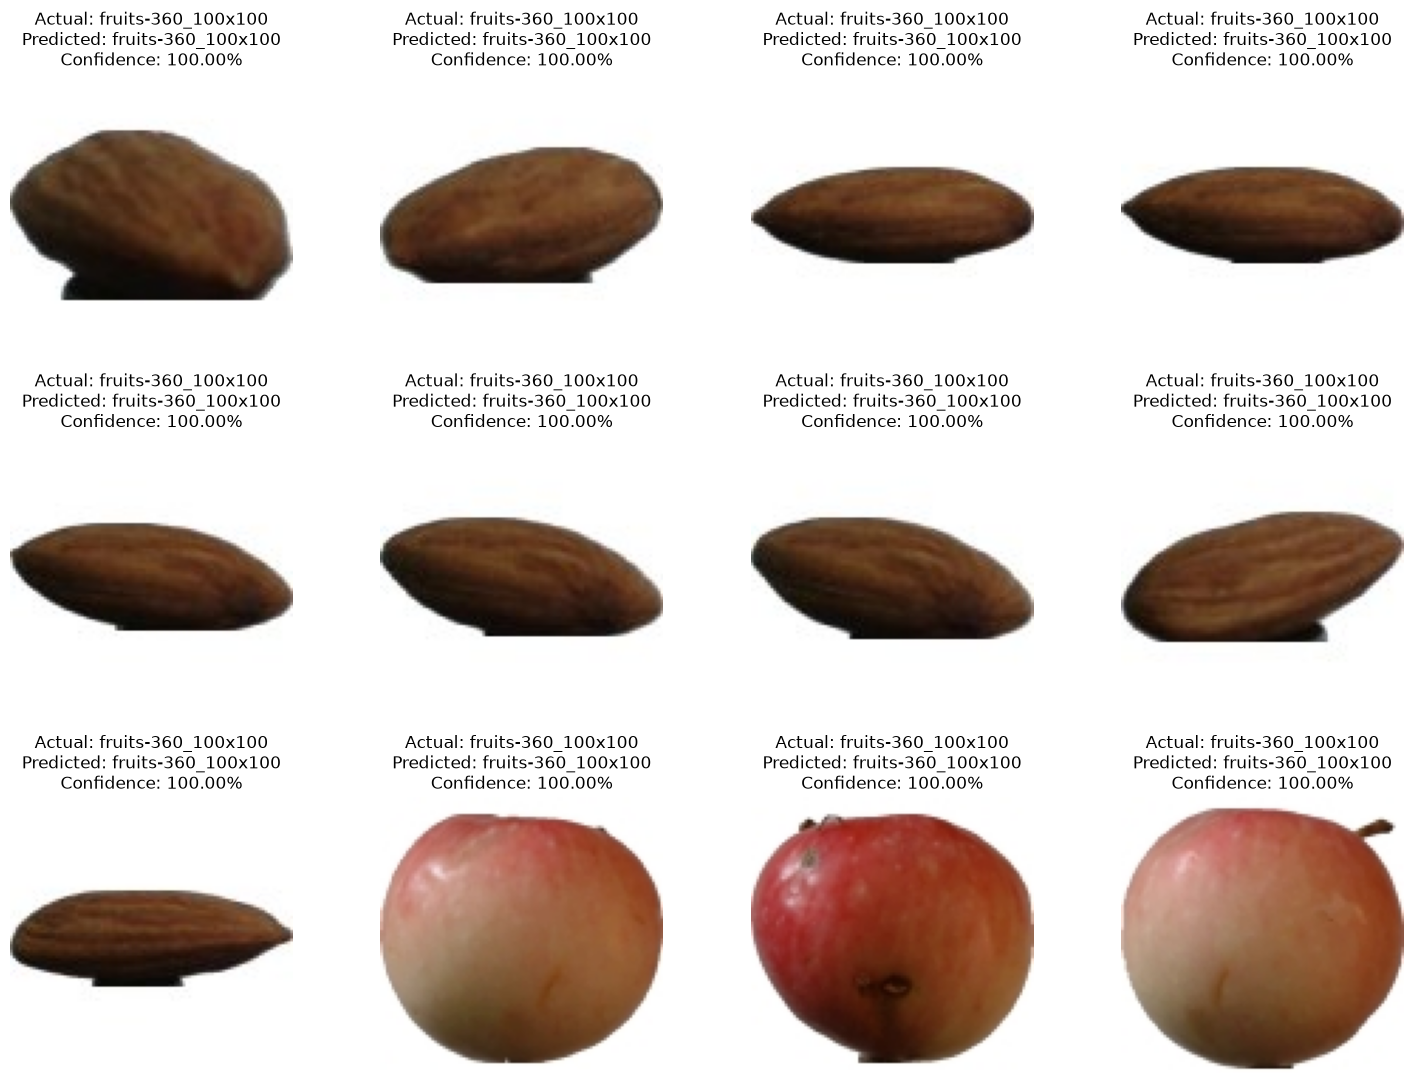

In [37]:

correct_sample = (
    prediction_results_df[
        prediction_results_df["Correct"]
    ]
    .head(12)
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(15, 11)
)

for ax in axes.flat:
    ax.axis("off")

for ax, (_, row) in zip(
    axes.flat,
    correct_sample.iterrows()
):
    try:
        ax.imshow(
            Image.open(row["Image_Path"])
        )
        ax.set_title(
            f"Actual: {row['Actual_Class']}\n"
            f"Predicted: {row['Predicted_Class']}\n"
            f"Confidence: {row['Confidence']:.2%}"
        )
    except Exception:
        ax.set_title("Image unavailable")

    ax.axis("off")

plt.tight_layout()
plt.show()


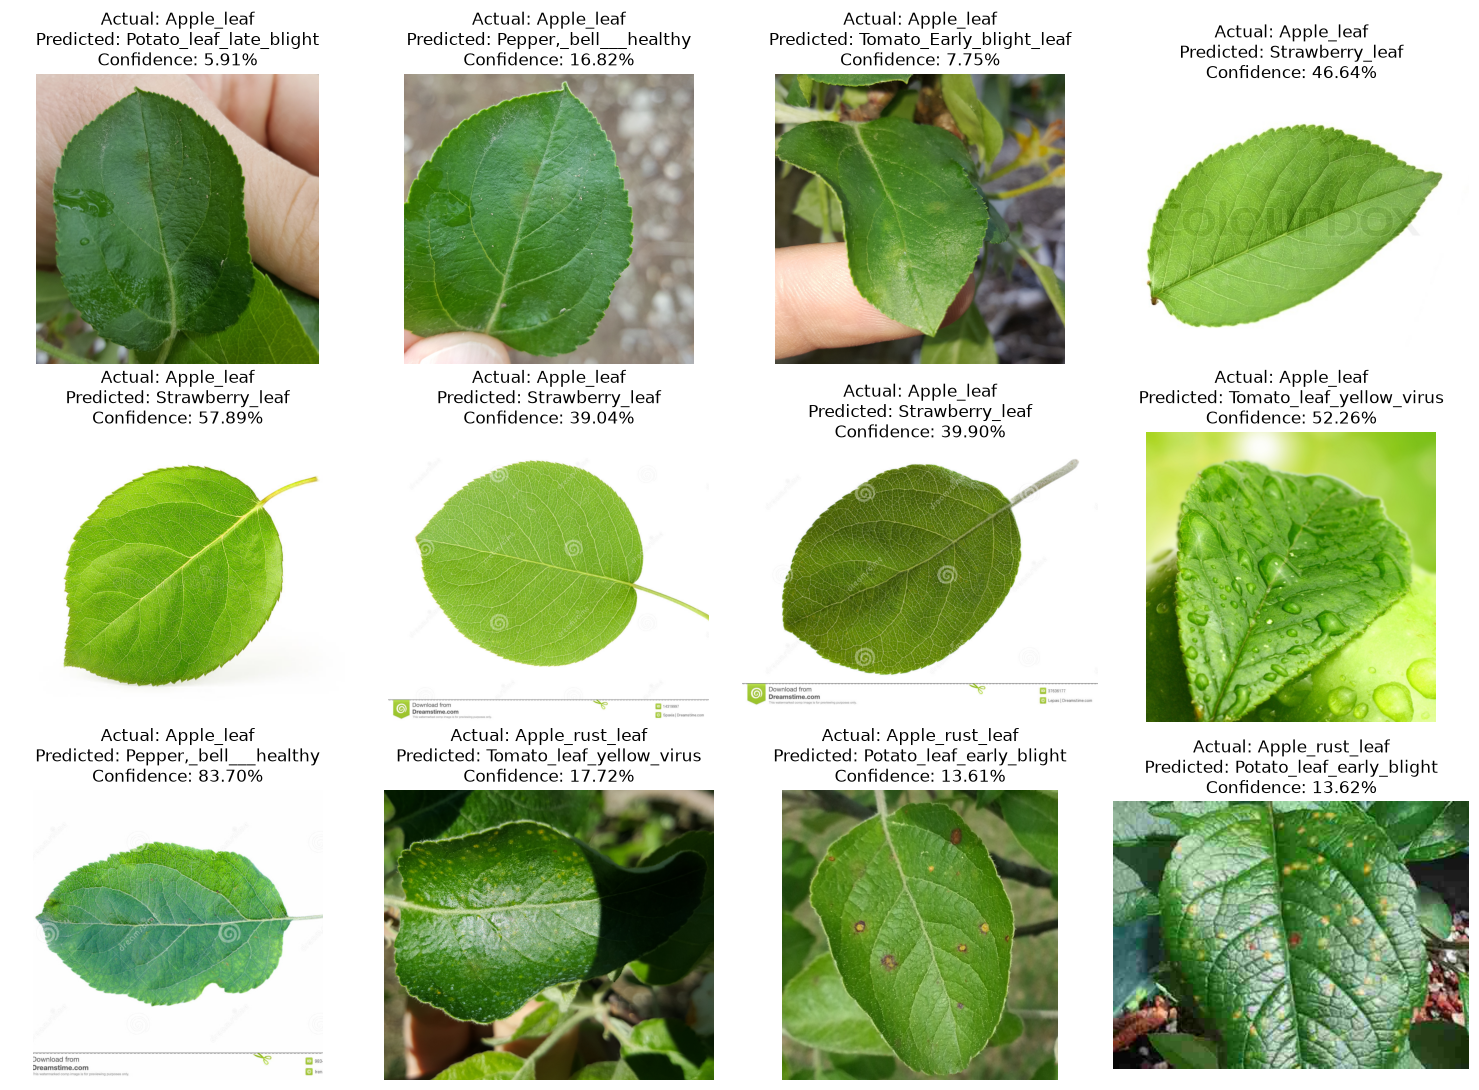

In [38]:

incorrect_sample = (
    prediction_results_df[
        ~prediction_results_df["Correct"]
    ]
    .head(12)
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(15, 11)
)

for ax in axes.flat:
    ax.axis("off")

for ax, (_, row) in zip(
    axes.flat,
    incorrect_sample.iterrows()
):
    try:
        ax.imshow(
            Image.open(row["Image_Path"])
        )
        ax.set_title(
            f"Actual: {row['Actual_Class']}\n"
            f"Predicted: {row['Predicted_Class']}\n"
            f"Confidence: {row['Confidence']:.2%}"
        )
    except Exception:
        ax.set_title("Image unavailable")

    ax.axis("off")

plt.tight_layout()
plt.show()


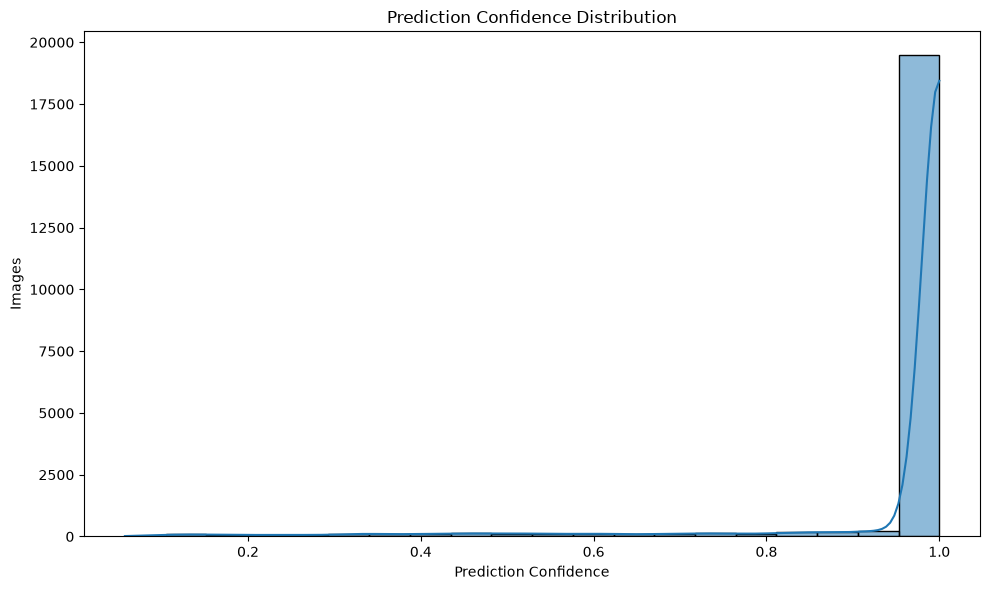

In [39]:

plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_results_df["Confidence"],
    bins=20,
    kde=True
)

plt.xlabel("Prediction Confidence")
plt.ylabel("Images")
plt.title("Prediction Confidence Distribution")
plt.tight_layout()
plt.show()


## Model Performance Comparison

In [40]:

overall_performance_df = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Score": test_accuracy
    },
    {
        "Metric": "Precision",
        "Score": test_precision
    },
    {
        "Metric": "Recall",
        "Score": test_recall
    },
    {
        "Metric": "F1-Score",
        "Score": test_f1
    }
])

print("CNN OVERALL PERFORMANCE")
display(overall_performance_df)


CNN OVERALL PERFORMANCE


,Metric,Score
0,Accuracy,0.958788
1,Precision,0.364972
2,Recall,0.377215
3,F1-Score,0.349739


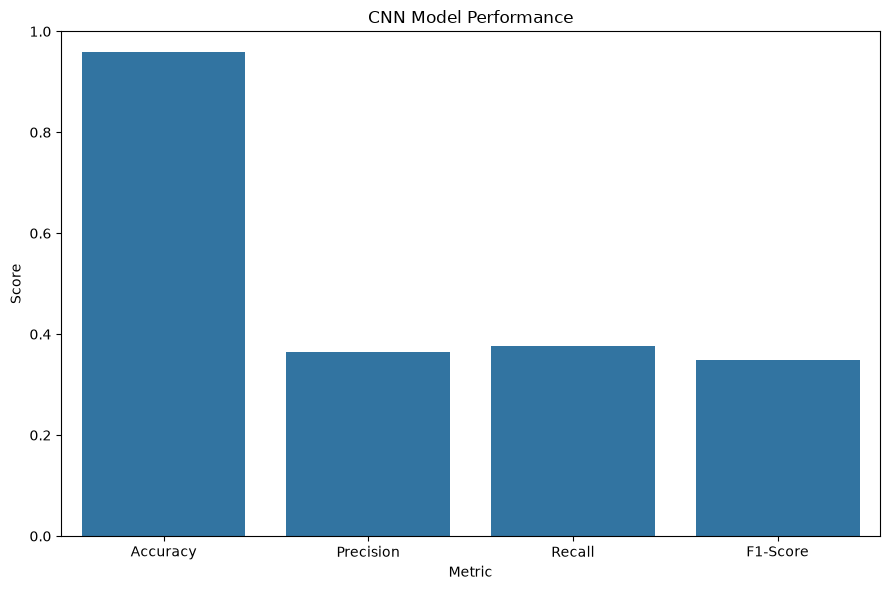

In [41]:

plt.figure(figsize=(9, 6))

sns.barplot(
    data=overall_performance_df,
    x="Metric",
    y="Score"
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("CNN Model Performance")
plt.tight_layout()
plt.show()


In [42]:

dataset_summary_performance_df = (
    prediction_results_df
    .groupby("Dataset")
    .agg(
        Images=("Correct", "count"),
        Accuracy=("Correct", "mean"),
        Average_Confidence=("Confidence", "mean")
    )
    .reset_index()
)

print("DATASET-WISE PERFORMANCE")
display(dataset_summary_performance_df)


DATASET-WISE PERFORMANCE


,Dataset,Images,Accuracy,Average_Confidence
0,Fruits-360,18295,1.000000,0.999986
1,PlantDoc,252,0.154762,0.327966
2,Vegetable Dataset,3000,0.775000,0.768179


In [43]:

class_performance_df = (
    class_report_only[
        ["precision", "recall", "f1-score", "support"]
    ]
    .sort_values("f1-score", ascending=False)
)

print("CLASS-WISE PERFORMANCE")
display(class_performance_df.head(20))


CLASS-WISE PERFORMANCE


,precision,recall,f1-score,support
fruits-360_100x100,0.995971,1.000000,0.997982,18295.0
Radish,0.984848,0.975000,0.979899,200.0
Cabbage,0.929730,0.860000,0.893506,200.0
Broccoli,0.878641,0.905000,0.891626,200.0
Pumpkin,0.865979,0.840000,0.852792,200.0
Cauliflower,0.836634,0.845000,0.840796,200.0
Cucumber,0.932515,0.760000,0.837466,200.0
Potato,1.000000,0.705000,0.826979,200.0
Capsicum,0.741036,0.930000,0.824834,200.0
Papaya,0.847059,0.720000,0.778378,200.0


## Save CNN Model & Results

In [44]:

# Save best model.
# ModelCheckpoint already creates it during training.
# This fallback guarantees a best-model file exists after training.

if not BEST_MODEL_PATH.exists():
    cnn_model.save(BEST_MODEL_PATH)

# Save final model.
cnn_model.save(FINAL_MODEL_PATH)

print("MODEL FILE STATUS")
print("Best Model:", BEST_MODEL_PATH)
print("Best Model Exists:", BEST_MODEL_PATH.exists())
print("Final Model:", FINAL_MODEL_PATH)
print("Final Model Exists:", FINAL_MODEL_PATH.exists())


MODEL FILE STATUS
Best Model: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
Best Model Exists: True
Final Model: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\final_cnn_model.keras
Final Model Exists: True


In [45]:

history_df.to_csv(
    HISTORY_PATH,
    index=True
)

overall_performance_df.to_csv(
    PERFORMANCE_PATH,
    index=False
)

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_PATH
)

pd.DataFrame(
    confusion_matrix_values,
    index=class_names,
    columns=class_names
).to_csv(
    CONFUSION_MATRIX_PATH
)

prediction_results_df.to_csv(
    PREDICTION_RESULTS_PATH,
    index=False
)

print("RESULT FILES SAVED")

for path in [
    HISTORY_PATH,
    PERFORMANCE_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSION_MATRIX_PATH,
    PREDICTION_RESULTS_PATH
]:
    print(path, "->", path.exists())


RESULT FILES SAVED
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\training_history.csv -> True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\cnn_performance_metrics.csv -> True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\classification_report.csv -> True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\confusion_matrix.csv -> True
E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Results\cnn_prediction_results.csv -> True


## Final CNN Training Report

In [46]:

print("FINAL DATASET COUNTS")
print("Training Images:", f"{train_generator.samples:,}")
print("Validation Images:", f"{validation_generator.samples:,}")
print("Test Images:", f"{test_generator.samples:,}")
print("Total Classes:", NUM_CLASSES)


FINAL DATASET COUNTS
Training Images: 234,290
Validation Images: 38,858
Test Images: 21,547
Total Classes: 82


In [47]:

print("FINAL CNN PERFORMANCE")

print(
    "Test Accuracy:",
    f"{test_accuracy:.4f}"
)

print(
    "Precision:",
    f"{test_precision:.4f}"
)

print(
    "Recall:",
    f"{test_recall:.4f}"
)

print(
    "F1-Score:",
    f"{test_f1:.4f}"
)

print(
    "Best Validation Accuracy:",
    f"{history_df['val_accuracy'].max():.4f}"
)

print(
    "Classes with test support:",
    len(supported_labels)
)

print(
    "Classes without test support:",
    NUM_CLASSES - len(supported_labels)
)


FINAL CNN PERFORMANCE
Test Accuracy: 0.9588
Precision: 0.3650
Recall: 0.3772
F1-Score: 0.3497
Best Validation Accuracy: 0.9202
Classes with test support: 43
Classes without test support: 39


In [48]:

training_status = (
    "COMPLETED"
    if (
        history is not None
        and BEST_MODEL_PATH.exists()
    )
    else "NOT COMPLETED"
)

print("FINAL CNN TRAINING REPORT")

report_items = [
    ("Training Images", f"{train_generator.samples:,}"),
    ("Validation Images", f"{validation_generator.samples:,}"),
    ("Test Images", f"{test_generator.samples:,}"),
    ("Total Classes", NUM_CLASSES),
    ("Image Size", IMAGE_SIZE),
    ("Batch Size", BATCH_SIZE),
    ("Epochs Configured", EPOCHS),
    ("Epochs Completed", len(history_df)),
    ("Model Architecture", "SmartAgriVision Custom CNN"),
    ("Best Model Path", BEST_MODEL_PATH),
    ("Final Model Path", FINAL_MODEL_PATH),
    ("Test Accuracy", f"{test_accuracy:.4f}"),
    ("Precision", f"{test_precision:.4f}"),
    ("Recall", f"{test_recall:.4f}"),
    ("F1-Score", f"{test_f1:.4f}"),
    ("Test Classes With Support", len(supported_labels)),
    ("Test Classes Without Support", NUM_CLASSES - len(supported_labels)),
    ("Training Status", training_status),
]

for key, value in report_items:
    print(f"{key}: {value}")


FINAL CNN TRAINING REPORT
Training Images: 234,290
Validation Images: 38,858
Test Images: 21,547
Total Classes: 82
Image Size: 128
Batch Size: 32
Epochs Configured: 3
Epochs Completed: 3
Model Architecture: SmartAgriVision Custom CNN
Best Model Path: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\best_cnn_model.keras
Final Model Path: E:\programming languages\DJANGO PROJECT\SmartAgriVision\SmartAgriVision\AgriVision\AI\notebooks\CNN_Models\final_cnn_model.keras
Test Accuracy: 0.9588
Precision: 0.3650
Recall: 0.3772
F1-Score: 0.3497
Test Classes With Support: 43
Test Classes Without Support: 39
Training Status: COMPLETED


In [49]:

print("FINAL MODEL SUMMARY")

print("Input Shape:", cnn_model.input_shape)
print("Output Shape:", cnn_model.output_shape)
print(
    "Total Parameters:",
    f"{cnn_model.count_params():,}"
)

output_files = [
    ("Best Model", BEST_MODEL_PATH),
    ("Final Model", FINAL_MODEL_PATH),
    ("Training History", HISTORY_PATH),
    ("Performance Metrics", PERFORMANCE_PATH),
    ("Classification Report", CLASSIFICATION_REPORT_PATH),
    ("Confusion Matrix", CONFUSION_MATRIX_PATH),
    ("Prediction Results", PREDICTION_RESULTS_PATH),
]

for name, path in output_files:
    print(
        f"{name} Exists:",
        path.exists()
    )

print()
print("CNN TRAINING PIPELINE COMPLETED")


FINAL MODEL SUMMARY
Input Shape: (None, 128, 128, 3)
Output Shape: (None, 82)
Total Parameters: 475,282
Best Model Exists: True
Final Model Exists: True
Training History Exists: True
Performance Metrics Exists: True
Classification Report Exists: True
Confusion Matrix Exists: True
Prediction Results Exists: True

CNN TRAINING PIPELINE COMPLETED
